iden   logNII/Ha   err_x   logOIII/Hb   err_y
 101     -0.326    0.039       -0.186    0.146
 151     -0.684    0.077        0.219    0.039
 202     -0.472    0.020       -0.367    0.056
 212     -0.613    0.038       -0.135    0.035
 285     -0.374    0.040       -0.210    0.157
 407     -0.598    0.021       -0.031    0.028
 459     -0.688    0.075        0.222    0.057
 553     -0.477    0.021       -0.451    0.105
 590     -0.563    0.020       -0.358    0.039
 680     -0.787    0.047        0.184    0.027
 812     -0.253    0.033        0.124    0.067
1086     -1.063    0.141        0.545    0.024
1103     -1.137    0.086        0.428    0.020
1233     -0.333    0.058        0.074    0.143


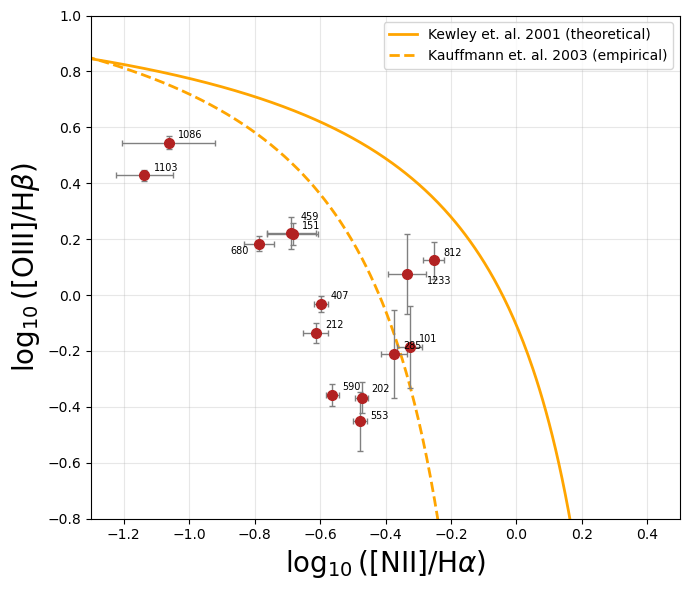

'NEW_BPT_diagram.png'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_csv("LINES_FITS/new_flag_combined.csv")

# Select row with maximum SFR for each object
df_sel = df.loc[
    df[(~df["flag_N2_SN"]) &
        (~df["flag_Hb_SN"]) &
        (~df["flag_Ha_SN"]) &
        (~df["flag_O3_SN"]) &
        (~df["flag_large_errorR1"]) &
        (df["iden"]!=1483)&
        (~df["flag_large_errorR2"])
    ]
    .groupby("iden")["SFR"]
    .idxmax()
]


# Extract values
x = df_sel["logR2"]
y = df_sel["logR1"]
xerr = df_sel["logR2_err"]
yerr = df_sel["logR1_err"]
labels = df_sel["iden"]

# ----------------------------
# Demarcation lines
# ----------------------------
x_line = np.linspace(-2, 0.045, 500)
x1_line = np.linspace(-2, 0.46, 500)

y_kewley = 0.61 / (x1_line - 0.47) + 1.19
y_kauffmann = 0.61 / (x_line - 0.05) + 1.3

# print values for sanity check
print("iden   logNII/Ha   err_x   logOIII/Hb   err_y")
for xi, yi, xei, yei, lab in zip(x, y, xerr, yerr, labels):
    print(f"{lab:4d}   {xi:8.3f}   {xei:6.3f}   {yi:10.3f}   {yei:6.3f}")

# ------------------------
# plot
#----------------------
plt.figure(figsize=(7,6))

plt.plot(x1_line, y_kewley, color='orange', linestyle='-', lw=2, label='Kewley et. al. 2001 (theoretical)')
plt.plot(x_line, y_kauffmann, color='orange', linestyle='--', lw=2, label='Kauffmann et. al. 2003 (empirical)')

# Data with error bars
plt.errorbar(
    x, y,
    xerr=xerr,
    yerr=yerr,
    fmt='o',
    color="firebrick",
    ecolor = "gray",
    capsize=2,
    elinewidth=1,
    markersize=7
)


# Manual label offsets for specific objects (dx, dy) in points
label_offsets = {
    202: (7, 3),
    553: (7, 0),
    459: (7, 8),
    151: (7, 2),
    1233: (14, -1),
    680: (-7,-2)
}


# Label points with iden (manual overrides where needed)
default_offset = (7, 2)

for xi, yi, lab in zip(x, y, labels):
    dx, dy = label_offsets.get(lab, default_offset)

    plt.annotate(
        str(lab),
        xy=(xi, yi),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=7,
        ha='left' if dx >= 0 else 'right',
        va='bottom' if dy >= 0 else 'top'
    )

# ----------------------------
# Plot formatting
# ----------------------------
plt.xlim(-1.3, 0.5)
plt.ylim(-0.8, 1)

plt.xlabel(r'$\log_{10}([\mathrm{NII}]/\mathrm{H}\alpha)$', fontsize=20)
plt.ylabel(r'$\log_{10}([\mathrm{OIII}]/\mathrm{H}\beta)$', fontsize=20)
#plt.title('BPT Diagram')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()

# Save the figure
output_path = "NEW_BPT_diagram.png"
#plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

output_path


iden   logSII/Ha   err_x   logOIII/Hb   err_y
 101     -0.398    0.053       -0.186    0.146
 151     -0.314    0.040        0.219    0.039
 202     -0.613    0.040       -0.367    0.056
 212     -0.463    0.040       -0.135    0.035
 285     -0.289    0.047       -0.210    0.157
 407     -0.377    0.018       -0.031    0.028
 459     -0.384    0.054        0.222    0.057
 553     -0.764    0.066       -0.431    0.087
 590     -0.486    0.024       -0.358    0.039
 680     -0.422    0.031        0.184    0.027
 812     -0.373    0.054        0.124    0.067
1081     -0.533    0.063        0.509    0.032
1086     -0.598    0.070        0.545    0.024
1103     -0.588    0.034        0.428    0.020
1233     -0.273    0.064        0.074    0.143


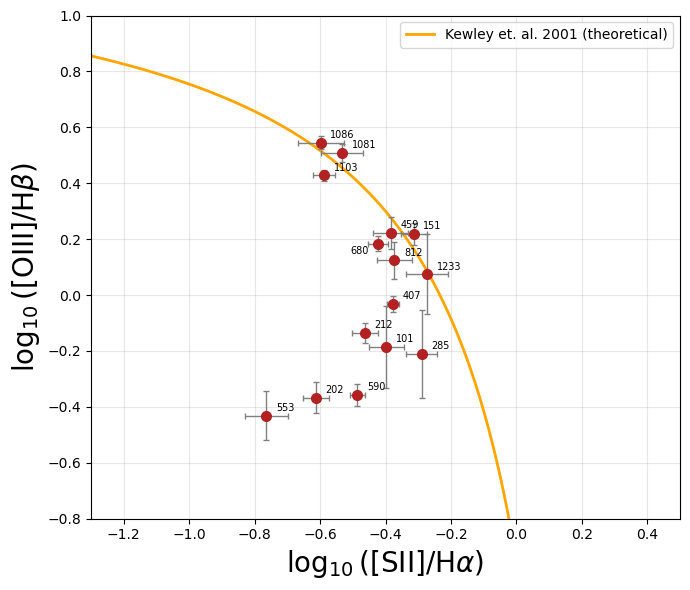

'NEW_SII_diagram.png'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_csv("LINES_FITS/new_flag_combined.csv")

# Select row with maximum SFR for each object
df_sel = df.loc[
    df[(~df["flag_SIIa_SN"]) &
        (~df["flag_SIIb_SN"]) &
        (~df["flag_Hb_SN"]) &
        (~df["flag_Ha_SN"]) &
        (~df["flag_O3_SN"]) &
        (~df["flag_large_errorR1"]) &
        (~df["flag_large_errorR3"])
    ]
    .groupby("iden")["SFR"]
    .idxmax()
]

# Extract values
x = df_sel["logR3"]
y = df_sel["logR1"]
xerr = df_sel["logR3_err"]
yerr = df_sel["logR1_err"]
labels = df_sel["iden"]

# ----------------------------
# Demarcation lines
# ----------------------------
x1_line = np.linspace(-2, 0.31, 500)

y_kewley = 0.72 / (x1_line - 0.32) + 1.30      #!!!!!!!!!!!!!!!!!!

# print values for sanity check
print("iden   logSII/Ha   err_x   logOIII/Hb   err_y")
for xi, yi, xei, yei, lab in zip(x, y, xerr, yerr, labels):
    print(f"{lab:4d}   {xi:8.3f}   {xei:6.3f}   {yi:10.3f}   {yei:6.3f}")

# ------------------------
# plot
#----------------------
plt.figure(figsize=(7,6))

plt.plot(x1_line, y_kewley, color='orange', linestyle='-', lw=2, label='Kewley et. al. 2001 (theoretical)')
#plt.plot(x_line, y_kauffmann, color='orange', linestyle='--', lw=2, label='Kauffmann et. al. 2003 (empirical)')

# Data with error bars
plt.errorbar(
    x, y,
    xerr=xerr,
    yerr=yerr,
    fmt='o',
    color="firebrick",
    ecolor = "gray",
    capsize=2,
    elinewidth=1,
    markersize=7
)


# Manual label offsets for specific objects (dx, dy) in points
label_offsets = {
#    202: (7, 3),
#    553: (7, 0),
#    459: (7, 8),
#    151: (7, 2),
#    1233: (14, -1),
     680: (-7,-2)
}


# Label points with iden (manual overrides where needed)
default_offset = (7, 2)

for xi, yi, lab in zip(x, y, labels):
    dx, dy = label_offsets.get(lab, default_offset)

    plt.annotate(
        str(lab),
        xy=(xi, yi),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=7,
        ha='left' if dx >= 0 else 'right',
        va='bottom' if dy >= 0 else 'top'
    )

# ----------------------------
# Plot formatting
# ----------------------------
plt.xlim(-1.3, 0.5)
plt.ylim(-0.8, 1)

plt.xlabel(r'$\log_{10}([\mathrm{SII}]/\mathrm{H}\alpha)$', fontsize=20)
plt.ylabel(r'$\log_{10}([\mathrm{OIII}]/\mathrm{H}\beta)$', fontsize=20)
#plt.title('BPT Diagram')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()

# Save the figure
output_path = "NEW_SII_diagram.png"
#plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

output_path
